# 07 Statistical Tests of Stylometric Differences

## Objective

In this notebook, I formally test whether the stylometric differences observed in the exploratory analysis are statistically significant across the five LLM families.

The previous semantic-map notebook showed that model families do not separate strongly in general sentence-embedding space. This means that broad semantic content alone does not clearly reveal model identity. Therefore, this notebook returns to the handcrafted stylometric features and tests whether writing-style features provide stronger evidence of model-specific fingerprints.

## Research Question

Can stylometric features distinguish texts generated by different LLMs?

## Statistical Question

For each stylometric feature, I test whether its distribution differs significantly across:

- GPT
- Claude
- DeepSeek
- Gemini
- Mistral

## Methods

I use:

1. Kruskal-Wallis omnibus tests to compare model families;
2. Benjamini-Hochberg FDR correction to control for multiple testing;
3. epsilon-squared effect sizes to evaluate practical importance;
4. genre-specific robustness checks to test whether model-family differences persist within genres;
5. post-hoc pairwise comparisons for the strongest features to identify which model pairs drive the omnibus differences.

The analysis uses the outputs generated by `python scripts/run_statistical_tests.py`.


In [83]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "final" / "stylometric_features.csv"
OVERALL_TEST_PATH = PROJECT_ROOT / "outputs" / "statistical_tests" / "kruskal_model_family_tests.csv"
GENRE_TEST_PATH = PROJECT_ROOT / "outputs" / "statistical_tests" / "kruskal_model_family_tests_by_genre.csv"
POSTHOC_TEST_PATH = PROJECT_ROOT / "outputs" / "statistical_tests" / "pairwise_posthoc_mannwhitney_tests.csv"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Project root:", PROJECT_ROOT)
print("Feature path:", FEATURE_PATH)
print("Overall test path:", OVERALL_TEST_PATH)
print("Genre test path:", GENRE_TEST_PATH)
print("Post-hoc test path:", POSTHOC_TEST_PATH)

Project root: /Users/violaawor/Desktop/LLM-sytlometric
Feature path: /Users/violaawor/Desktop/LLM-sytlometric/data/features/final/stylometric_features.csv
Overall test path: /Users/violaawor/Desktop/LLM-sytlometric/outputs/statistical_tests/kruskal_model_family_tests.csv
Genre test path: /Users/violaawor/Desktop/LLM-sytlometric/outputs/statistical_tests/kruskal_model_family_tests_by_genre.csv
Post-hoc test path: /Users/violaawor/Desktop/LLM-sytlometric/outputs/statistical_tests/pairwise_posthoc_mannwhitney_tests.csv


## 1. Load feature and statistical-test outputs

In this code section, I load the files produced by the modular statistical-testing pipeline. I use the feature matrix as the base analytical dataset, then load the three statistical outputs:

- the overall Kruskal-Wallis results;
- the genre-specific Kruskal-Wallis robustness results;
- the pairwise Mann-Whitney U post-hoc results.

This step is important because the notebook should not recompute the statistical analysis manually. The script `python scripts/run_statistical_tests.py` produces the official outputs, and this notebook documents, visualizes, and interprets them.


In [84]:
features_df = pd.read_csv(FEATURE_PATH)
overall_tests = pd.read_csv(OVERALL_TEST_PATH)
genre_tests = pd.read_csv(GENRE_TEST_PATH)
posthoc_results = pd.read_csv(POSTHOC_TEST_PATH)

feature_columns = [col for col in features_df.columns if col.startswith("stylo_")]

print("Feature dataset shape:", features_df.shape)
print("Number of stylometric features:", len(feature_columns))
print("Overall test shape:", overall_tests.shape)
print("Genre-specific test shape:", genre_tests.shape)
print("Pairwise post-hoc test shape:", posthoc_results.shape)

print("Overall Kruskal-Wallis results preview:")
display(overall_tests.head())

print("Pairwise post-hoc results preview:")
display(posthoc_results.head())

Feature dataset shape: (1000, 55)
Number of stylometric features: 43
Overall test shape: (43, 15)
Genre-specific test shape: (172, 16)
Pairwise post-hoc test shape: (100, 14)
Overall Kruskal-Wallis results preview:


,feature,kruskal_h,p_value,epsilon_squared,effect_size_interpretation,max_mean_model,min_mean_model,max_mean,min_mean,mean_difference,n_observations,n_groups,p_value_fdr,significant_fdr_0_05,neg_log10_p_fdr
0,stylo_sentence_length_max,312.009378,2.779310e-66,0.309557,large,DeepSeek,Claude,36.785000,25.550000,11.235000,1000,5,1.195103e-64,True,63.922594
1,stylo_comma_count,297.000150,4.807047e-63,0.294473,large,Gemini,Claude,20.355000,12.945000,7.410000,1000,5,6.890101e-62,True,61.161774
2,stylo_long_sentence_ratio,297.625386,3.523848e-63,0.295101,large,DeepSeek,Claude,0.372563,0.071069,0.301494,1000,5,7.576273e-62,True,61.120544
3,stylo_word_count,293.561608,2.651703e-62,0.291017,large,DeepSeek,Mistral,218.785000,203.280000,15.505000,1000,5,2.850581e-61,True,60.545067
4,stylo_comma_per_100_words,275.496743,2.083868e-58,0.272861,large,Gemini,Claude,9.707183,6.181178,3.526005,1000,5,1.792127e-57,True,56.746631


Pairwise post-hoc results preview:


,feature,group_a,group_b,mannwhitney_u,p_value,mean_group_a,mean_group_b,mean_difference_a_minus_b,absolute_mean_difference,higher_mean_group,lower_mean_group,p_value_fdr,significant_fdr_0_05,neg_log10_p_fdr
0,stylo_avg_word_length,Claude,DeepSeek,34397.5,1.353070e-35,6.069700,5.087138,0.982563,0.982563,Claude,DeepSeek,1.040823e-34,True,33.982623
1,stylo_avg_word_length,Claude,GPT,31820.0,1.560663e-24,6.069700,5.334333,0.735368,0.735368,Claude,GPT,6.502764e-24,True,23.186902
2,stylo_avg_word_length,DeepSeek,Gemini,9057.0,2.944439e-21,5.087138,5.667840,-0.580702,0.580702,Gemini,DeepSeek,1.051585e-20,True,19.978155
3,stylo_avg_word_length,Claude,Mistral,30757.5,1.349820e-20,6.069700,5.362520,0.707180,0.707180,Claude,Mistral,4.354259e-20,True,19.361086
4,stylo_avg_word_length,Claude,Gemini,27221.5,4.217141e-10,6.069700,5.667840,0.401861,0.401861,Claude,Gemini,6.487909e-10,True,9.187895


### Interpretation of loaded outputs

The feature dataset contains **1,000 generated texts** and **55 total columns**, including **43 stylometric feature columns**. This confirms that the statistical analysis is based on the full balanced corpus created earlier in the project.

The overall Kruskal-Wallis table contains **43 rows**, one omnibus test for each stylometric feature. The genre-specific table contains **172 rows**, which is expected because the same 43 features are tested within each of the four genres: \(43 \times 4 = 172\).

The post-hoc table contains **100 pairwise Mann-Whitney U tests**. This comes from testing the top 10 strongest features across the 10 possible model-family pairs. With five model families, the number of pairwise comparisons is:

\[
\binom{5}{2} = 10
\]

Therefore, \(10\) features multiplied by \(10\) model-pair comparisons gives \(100\) post-hoc tests.

This confirms that the notebook is using a complete statistical workflow: omnibus testing, FDR correction, effect-size analysis, genre robustness checks, and pairwise model-pair diagnosis.


## 2. Statistical method

### Kruskal-Wallis test

For each stylometric feature, I use the Kruskal-Wallis test to compare the five model families. This is a non-parametric omnibus test. It is appropriate here because many stylometric variables are counts, ratios, or skewed distributions, so a normality assumption would be too strong.

For a feature \(X\), the null and alternative hypotheses are:

\[
H_0: F_{GPT}(X) = F_{Claude}(X) = F_{DeepSeek}(X) = F_{Gemini}(X) = F_{Mistral}(X)
\]

\[
H_1: \text{At least one model family has a different distribution of } X
\]

The test statistic is:

\[
H = \frac{12}{N(N+1)} \sum_{i=1}^{k} n_i(\bar{R}_i - \bar{R})^2
\]

where:

- \(N\) is the total number of observations;
- \(k\) is the number of model families;
- \(n_i\) is the number of observations in group \(i\);
- \(\bar{R}_i\) is the average rank in group \(i\);
- \(\bar{R}\) is the overall average rank.

### FDR correction

Because I test 43 stylometric features, I correct the p-values using Benjamini-Hochberg false discovery rate correction. This reduces the risk of falsely identifying features as significant simply because many tests were performed.

### Effect size

I use epsilon-squared to estimate the strength of the Kruskal-Wallis effect:

\[
\epsilon^2 = \frac{H - k + 1}{N - k}
\]

where:

- \(H\) is the Kruskal-Wallis statistic;
- \(k\) is the number of model families;
- \(N\) is the total number of observations.

The interpretation used here is:

- negligible: \( \epsilon^2 < 0.01 \)
- small: \( 0.01 \leq \epsilon^2 < 0.06 \)
- medium: \( 0.06 \leq \epsilon^2 < 0.14 \)
- large: \( \epsilon^2 \geq 0.14 \)

In [85]:
total_features = len(overall_tests)
significant_features = int(overall_tests["significant_fdr_0_05"].sum())

effect_counts = overall_tests["effect_size_interpretation"].value_counts()

print("Total features tested:", total_features)
print("Significant features after FDR correction:", significant_features)
print("\nEffect size counts:")
display(effect_counts)

summary_table = pd.DataFrame({
    "metric": [
        "Total stylometric features tested",
        "Significant after FDR correction",
        "Not significant after FDR correction",
        "Share significant"
    ],
    "value": [
        total_features,
        significant_features,
        total_features - significant_features,
        significant_features / total_features
    ]
})

display(summary_table)

Total features tested: 43
Significant features after FDR correction: 41

Effect size counts:


effect_size_interpretation
large         22
small         11
medium         7
negligible     3
Name: count, dtype: int64

,metric,value
0,Total stylometric features tested,43.000000
1,Significant after FDR correction,41.000000
2,Not significant after FDR correction,2.000000
3,Share significant,0.953488


### Interpretation of the overall statistical summary

The results show that **41 out of 43 stylometric features** are statistically significant after Benjamini-Hochberg FDR correction. This means that approximately **95.35%** of the extracted writing-style features differ across the five model families.

The effect-size distribution is also important. There are:

- **22 large effects**;
- **7 medium effects**;
- **11 small effects**;
- **3 negligible effects**.

This means the result is not only statistically significant because the dataset has 1,000 texts. Many of the differences are large enough to be practically meaningful.

As the data scientist conducting this project, I interpret this as strong evidence that GPT, Claude, DeepSeek, Gemini, and Mistral do not generate stylistically identical texts under the same prompt and word-count conditions. The model-family signal is visible in the stylometric feature space.


In [86]:
top_significant = overall_tests[
    overall_tests["significant_fdr_0_05"] == True
].sort_values(
    ["p_value_fdr", "epsilon_squared"],
    ascending=[True, False]
).head(15)

display_columns = [
    "feature",
    "kruskal_h",
    "p_value_fdr",
    "epsilon_squared",
    "effect_size_interpretation",
    "max_mean_model",
    "min_mean_model",
    "max_mean",
    "min_mean",
    "mean_difference",
]

display(top_significant[display_columns])

,feature,kruskal_h,p_value_fdr,epsilon_squared,effect_size_interpretation,max_mean_model,min_mean_model,max_mean,min_mean,mean_difference
0,stylo_sentence_length_max,312.009378,1.195103e-64,0.309557,large,DeepSeek,Claude,36.785000,25.550000,11.235000
1,stylo_comma_count,297.000150,6.890101e-62,0.294473,large,Gemini,Claude,20.355000,12.945000,7.410000
2,stylo_long_sentence_ratio,297.625386,7.576273e-62,0.295101,large,DeepSeek,Claude,0.372563,0.071069,0.301494
3,stylo_word_count,293.561608,2.850581e-61,0.291017,large,DeepSeek,Mistral,218.785000,203.280000,15.505000
4,stylo_comma_per_100_words,275.496743,1.792127e-57,0.272861,large,Gemini,Claude,9.707183,6.181178,3.526005
5,stylo_sentence_length_std,273.477108,4.069802e-57,0.270831,large,DeepSeek,Claude,8.472700,5.237477,3.235223
6,stylo_function_word_count,268.341940,4.462127e-56,0.265670,large,DeepSeek,Claude,75.145000,56.055000,19.090000
7,stylo_function_word_ratio,235.777850,4.045854e-49,0.232943,large,GPT,Claude,0.345798,0.267238,0.078560
8,stylo_avg_word_length,229.604693,7.672160e-48,0.226738,large,Claude,DeepSeek,6.069700,5.087138,0.982563
9,stylo_sentence_length_range,207.219602,4.527682e-43,0.204241,large,DeepSeek,Claude,28.780000,18.825000,9.955000


### Interpretation of the top significant features

The top 15 significant features show that the strongest model-family differences occur in sentence structure, punctuation, word count, function-word use, lexical style, and AI-marker usage.

The strongest feature is `stylo_sentence_length_max`, with an epsilon-squared value of about **0.310**. DeepSeek has the highest mean maximum sentence length (**36.79 words**), while Claude has the lowest (**25.55 words**). This means DeepSeek tends to produce at least some very long sentences, while Claude avoids extremely long sentence constructions.

Comma-related features are also among the strongest results. `stylo_comma_count` and `stylo_comma_per_100_words` are highest for Gemini and lowest for Claude. Gemini averages about **20.36 commas per text**, compared with about **12.95** for Claude. Gemini also has about **9.71 commas per 100 words**, compared with about **6.18** for Claude. This suggests that Gemini relies more heavily on comma-separated clauses and produces more comma-dense prose.

DeepSeek has the highest values for `stylo_long_sentence_ratio`, `stylo_word_count`, `stylo_sentence_length_std`, `stylo_function_word_count`, `stylo_sentence_length_range`, and `stylo_avg_sentence_length`. Taken together, these results indicate that DeepSeek tends to generate longer, more expansive, and more structurally variable prose.

Claude has the highest `stylo_avg_word_length`, `stylo_character_count`, `stylo_type_token_ratio`, and `stylo_period_per_100_words`. This suggests that Claude's writing is more character-dense, uses longer words on average, and shows comparatively high lexical variety.

GPT has the highest `stylo_function_word_ratio`, meaning that GPT uses the largest proportion of grammatical or function words relative to its total word count.

Gemini has the highest `stylo_ai_marker_ratio`, suggesting stronger use of the selected polished or AI-associated lexical markers in this corpus.

Overall, the top features show that model-family differences are not confined to one area. The models differ across several stylistic systems at once: sentence rhythm, punctuation habits, lexical density, discourse structure, and marker usage.


## 3. Feature-family summary

The individual test results are useful, but I also need to understand which broader stylometric families carry the strongest model-family signal. I group the 43 features into interpretable families: length and sentence structure, punctuation, casing, lexical diversity, markers/function words, and readability.

This helps connect the statistical outputs back to the project argument: if significant features are spread across several families, then model style is a broad fingerprint rather than a single isolated artifact.


In [87]:
feature_family_map = {
    "Length and sentence structure": [
        "stylo_word_count",
        "stylo_character_count",
        "stylo_sentence_count",
        "stylo_avg_word_length",
        "stylo_avg_sentence_length",
        "stylo_sentence_length_std",
        "stylo_sentence_length_min",
        "stylo_sentence_length_max",
        "stylo_sentence_length_range",
        "stylo_short_sentence_ratio",
        "stylo_long_sentence_ratio",
    ],
    "Punctuation": [
        "stylo_punctuation_count",
        "stylo_comma_count",
        "stylo_period_count",
        "stylo_question_mark_count",
        "stylo_exclamation_count",
        "stylo_semicolon_count",
        "stylo_colon_count",
        "stylo_dash_count",
        "stylo_quote_count",
        "stylo_punctuation_per_100_words",
        "stylo_comma_per_100_words",
        "stylo_period_per_100_words",
    ],
    "Casing": [
        "stylo_uppercase_word_count",
        "stylo_titlecase_word_count",
        "stylo_uppercase_char_ratio",
    ],
    "Lexical diversity": [
        "stylo_type_token_ratio",
        "stylo_hapax_legomena_ratio",
        "stylo_repeated_word_ratio",
        "stylo_yules_k",
        "stylo_simpson_diversity",
        "stylo_honores_r",
        "stylo_mattr_50",
    ],
    "Markers and function words": [
        "stylo_function_word_count",
        "stylo_function_word_ratio",
        "stylo_ai_marker_count",
        "stylo_ai_marker_ratio",
        "stylo_transition_marker_count",
        "stylo_transition_marker_ratio",
        "stylo_hedging_marker_count",
        "stylo_hedging_marker_ratio",
    ],
    "Readability": [
        "stylo_flesch_reading_ease",
        "stylo_gunning_fog",
    ],
}

feature_to_family = {
    feature: family
    for family, features in feature_family_map.items()
    for feature in features
}

overall_tests = overall_tests.copy()
overall_tests["feature_family"] = overall_tests["feature"].map(feature_to_family).fillna("Other")

family_summary = (
    overall_tests
    .groupby("feature_family")
    .agg(
        total_features=("feature", "count"),
        significant_features=("significant_fdr_0_05", "sum"),
        mean_epsilon_squared=("epsilon_squared", "mean"),
        median_epsilon_squared=("epsilon_squared", "median"),
        max_epsilon_squared=("epsilon_squared", "max"),
    )
    .reset_index()
)

family_summary["share_significant"] = (
    family_summary["significant_features"] / family_summary["total_features"]
)

family_summary = family_summary.sort_values(
    ["share_significant", "mean_epsilon_squared"],
    ascending=[False, False],
)

display(family_summary)


,feature_family,total_features,significant_features,mean_epsilon_squared,median_epsilon_squared,max_epsilon_squared,share_significant
1,Length and sentence structure,11,11,0.205025,0.204241,0.309557,1.000000
2,Lexical diversity,7,7,0.125747,0.138800,0.194020,1.000000
5,Readability,2,2,0.116912,0.116912,0.144736,1.000000
3,Markers and function words,8,8,0.116342,0.105218,0.265670,1.000000
4,Punctuation,12,11,0.117454,0.064447,0.294473,0.916667
0,Casing,3,2,0.013066,0.012086,0.027111,0.666667


### Interpretation of feature-family summary

The feature-family summary shows that the model-family signal is distributed across multiple stylometric families rather than being concentrated in one isolated metric.

The strongest family by mean epsilon-squared is **Length and sentence structure**, with all **11 out of 11 features significant** and a mean epsilon-squared of about **0.205**. This indicates that sentence rhythm, sentence length, sentence variability, word count, and character count are central to model differentiation.

**Lexical diversity** is also strong: all **7 out of 7 lexical diversity features** are significant, with a mean epsilon-squared of about **0.126**. This shows that the models differ in vocabulary richness and repetition patterns.

**Readability** has **2 out of 2 significant features**, while **Markers and function words** has **8 out of 8 significant features**. This means that model differences also appear in discourse construction, grammatical-word usage, hedging or transition markers, and readability-related complexity.

**Punctuation** has **11 out of 12 significant features**, showing that punctuation style is highly informative, especially comma and period usage. **Casing** is the weakest family: only **2 out of 3 features** are significant and the mean effect size is small. This makes sense because the prompts requested ordinary prose, so uppercase patterns should be less distinctive.

This strengthens the stylometric interpretation of the project. A model fingerprint is more convincing when it appears across several writing dimensions rather than only one surface-level feature such as word count.


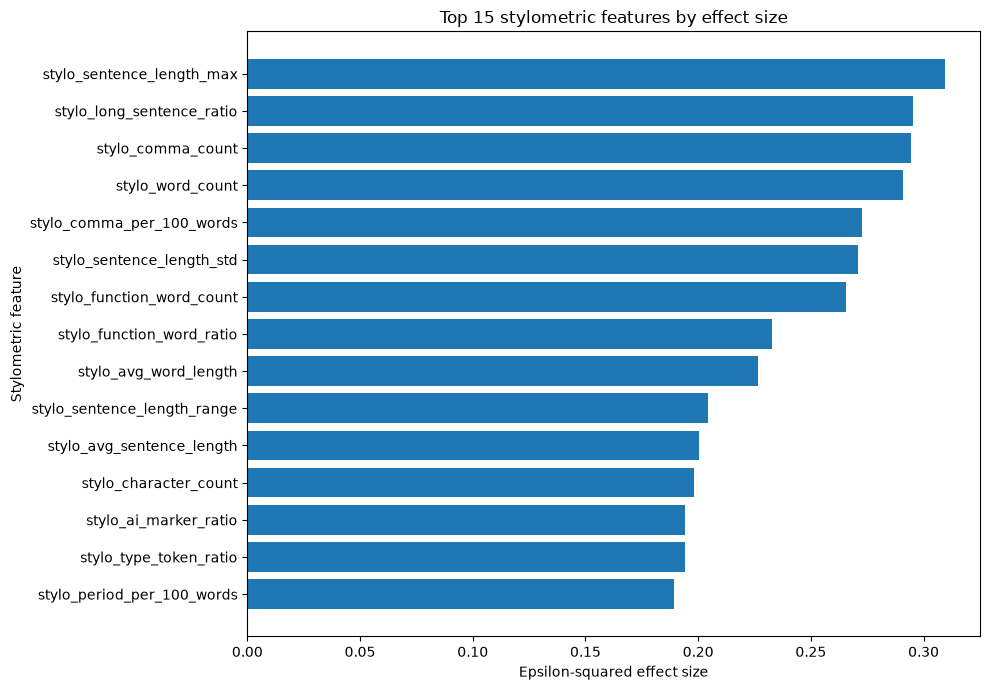

In [88]:
top_effects = overall_tests.sort_values("epsilon_squared", ascending=False).head(15)

plot_labels = top_effects["feature"].astype(str).iloc[::-1].tolist()
plot_values = top_effects["epsilon_squared"].astype(float).iloc[::-1].to_numpy()

plt.figure(figsize=(10, 7))
plt.barh(plot_labels, plot_values)
plt.xlabel("Epsilon-squared effect size")
plt.ylabel("Stylometric feature")
plt.title("Top 15 stylometric features by effect size")
plt.tight_layout()
plt.show()


### Interpretation of the effect-size plot

The effect-size plot ranks the strongest stylometric differences by epsilon-squared. The chart shows that the largest model-family effects are concentrated in sentence length, punctuation, word count, function-word usage, lexical density, and AI-marker usage.

The largest effect is maximum sentence length, followed closely by comma count, long-sentence ratio, word count, comma density, sentence-length variability, and function-word count. These are concrete writing behaviours, not abstract statistical artifacts.

The most important point from this chart is that the top bars are all above the **large-effect threshold of 0.14**. This means the strongest model-family differences are not merely detectable; they are substantively meaningful.

For my research question, this plot provides clear evidence that model identity is visible in the stylometric feature space. The strongest signatures are structural and stylistic: how long the models make sentences, how often they use commas, how much they vary sentence length, and how they distribute function words.


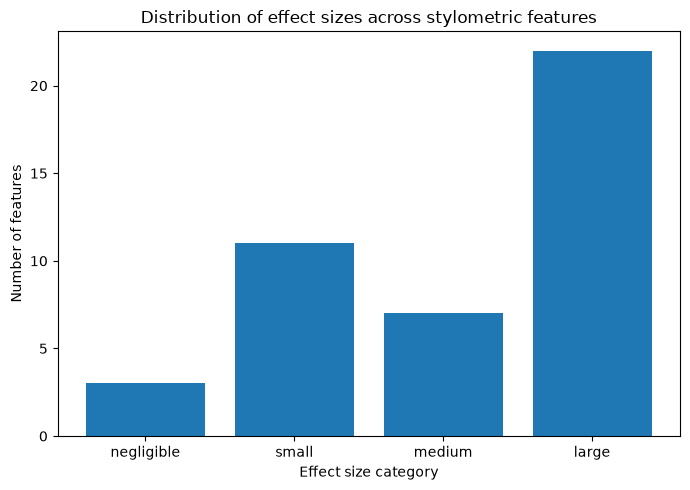

effect_size_interpretation
negligible     3
small         11
medium         7
large         22
Name: count, dtype: int64

In [89]:
effect_order = ["negligible", "small", "medium", "large"]
effect_distribution = (
    overall_tests["effect_size_interpretation"]
    .value_counts()
    .reindex(effect_order)
    .fillna(0)
)

plt.figure(figsize=(7, 5))
plt.bar(effect_distribution.index.astype(str), effect_distribution.to_numpy(dtype=float))
plt.xlabel("Effect size category")
plt.ylabel("Number of features")
plt.title("Distribution of effect sizes across stylometric features")
plt.tight_layout()
plt.show()

display(effect_distribution)

### Interpretation of the effect-size distribution

The effect-size distribution confirms that most statistically significant differences are meaningful in magnitude. The largest category is **large effects**, with **22 features**. This means that approximately half of the stylometric feature set shows strong separation between model families.

There are also **7 medium effects** and **11 small effects**. Only **3 features** have negligible effects. This supports the argument that model-family differences are broad and systematic rather than limited to a small number of isolated features.

For this project, this result is important because it shows that model-specific style is not just detectable. It is detectable across many measurable writing dimensions.


In [90]:
significant_by_effect = pd.crosstab(
    overall_tests["effect_size_interpretation"],
    overall_tests["significant_fdr_0_05"]
)

display(significant_by_effect)

significant_fdr_0_05,False,True
effect_size_interpretation,,
large,0,22
medium,0,7
negligible,2,1
small,0,11


### Interpretation of significance by effect size

This table connects statistical significance with practical effect size.

All **22 large-effect features** are significant after FDR correction, and all **7 medium-effect features** are also significant. The **11 small-effect features** are also significant. This confirms that the strongest stylometric differences are both statistically reliable and practically meaningful.

The table also shows that **two negligible-effect features are not significant**, while one negligible-effect feature is significant. This is analytically useful because it shows that the testing pipeline is not automatically treating every metric as meaningful. Some features genuinely carry little model-family information.

This makes the significant results more credible because the pipeline distinguishes strong stylometric signals from weak or uninformative ones.


In [91]:
not_significant = overall_tests[
    overall_tests["significant_fdr_0_05"] == False
].sort_values("p_value_fdr")

display(not_significant[
    [
        "feature",
        "p_value",
        "p_value_fdr",
        "epsilon_squared",
        "effect_size_interpretation",
        "max_mean_model",
        "min_mean_model",
    ]
])

,feature,p_value,p_value_fdr,epsilon_squared,effect_size_interpretation,max_mean_model,min_mean_model
41,stylo_question_mark_count,0.656882,0.672522,0.0,negligible,GPT,Gemini
42,stylo_uppercase_char_ratio,0.800468,0.800468,0.0,negligible,GPT,Gemini


### Interpretation of non-significant features

Only two stylometric features are not significant after FDR correction: `stylo_question_mark_count` and `stylo_uppercase_char_ratio`.

This is interpretable. Question marks are likely rare because most generated outputs are prose responses rather than interrogative texts. Uppercase character ratio is also expected to be low and fairly stable because the prompts ask for ordinary prose, not titles, headings, or emphatic formatting.

These non-significant features are useful because they show that not every extracted feature is equally informative. The strongest model-family signal comes from sentence structure, punctuation density, lexical diversity, function-word use, and readability-related features, not from question marks or uppercase character patterns.

In [92]:
selected_features = [
    "stylo_sentence_length_max",
    "stylo_comma_count",
    "stylo_long_sentence_ratio",
    "stylo_word_count",
    "stylo_function_word_ratio",
    "stylo_avg_word_length",
    "stylo_ai_marker_ratio",
    "stylo_type_token_ratio",
]

selected_means = (
    features_df.groupby("model_family")[selected_features]
    .mean()
    .round(3)
)

display(selected_means)

,stylo_sentence_length_max,stylo_comma_count,stylo_long_sentence_ratio,stylo_word_count,stylo_function_word_ratio,stylo_avg_word_length,stylo_ai_marker_ratio,stylo_type_token_ratio
model_family,,,,,,,,
Claude,25.550,12.945,0.071,209.850,0.267,6.070,0.002,0.719
DeepSeek,36.785,18.230,0.373,218.785,0.343,5.087,0.002,0.695
GPT,29.165,16.435,0.185,209.160,0.346,5.334,0.006,0.668
Gemini,35.450,20.355,0.318,209.650,0.309,5.668,0.007,0.717
Mistral,30.165,15.680,0.199,203.280,0.317,5.363,0.002,0.705


### Interpretation of selected model means

The selected mean table gives concrete stylistic meaning to the statistical results.

DeepSeek stands out for longer structural units. It has the highest maximum sentence length (**36.785**), the highest long-sentence ratio (**0.373**), and the highest word count (**218.785**). This supports the interpretation that DeepSeek tends to produce longer and more expansive prose.

Gemini stands out for comma use and AI-style marker ratio. It has the highest comma count (**20.355**) and the highest selected AI-marker ratio (**0.007**), suggesting more clause-linking punctuation and more polished marker language.

Claude stands out for average word length and type-token ratio. It has the highest average word length (**6.070**) and the highest type-token ratio (**0.719**). This suggests denser wording and comparatively higher lexical variety. Claude also has high character density, meaning that its texts are not necessarily longer in word count but tend to contain longer words or more characters per word.

GPT stands out in function-word ratio (**0.346**), suggesting a distinctive grammatical composition pattern, with a higher proportion of function words relative to total output length.

Mistral has the lowest word count among the selected means (**203.280**) and does not dominate the strongest selected features. In this table, Mistral appears less extreme than DeepSeek, Gemini, Claude, and GPT on the main top-ranked signals.

These differences give the statistical results interpretable stylistic meaning. The models are not merely different numerically; they display different writing behaviours.


## 4. Post-hoc pairwise comparisons for the strongest features

The Kruskal-Wallis test is an omnibus test. It tells me whether at least one model family differs from the others, but it does not identify every specific model pair that differs.

For that reason, I use the updated post-hoc output generated by `src/statistical_tests.py`. The pipeline runs pairwise Mann-Whitney U tests for the top 10 strongest significant stylometric features and applies FDR correction to the post-hoc p-values.

This section does not rerun the post-hoc tests inside the notebook. Instead, it reads the saved file:

`outputs/statistical_tests/pairwise_posthoc_mannwhitney_tests.csv`

This keeps the notebook aligned with the modular project structure, where scripts generate analysis outputs and notebooks interpret them.

In [93]:
total_pairwise_tests = len(posthoc_results)
significant_pairwise_tests = int(posthoc_results["significant_fdr_0_05"].sum())

posthoc_summary = pd.DataFrame({
    "metric": [
        "Total pairwise post-hoc tests",
        "Significant pairwise tests after FDR correction",
        "Not significant after FDR correction",
        "Share significant",
    ],
    "value": [
        total_pairwise_tests,
        significant_pairwise_tests,
        total_pairwise_tests - significant_pairwise_tests,
        significant_pairwise_tests / total_pairwise_tests,
    ],
})

display(posthoc_summary)

posthoc_display_columns = [
    "feature",
    "group_a",
    "group_b",
    "p_value_fdr",
    "mean_group_a",
    "mean_group_b",
    "mean_difference_a_minus_b",
    "higher_mean_group",
    "lower_mean_group",
]

top_pairwise = (
    posthoc_results[posthoc_results["significant_fdr_0_05"] == True]
    .sort_values(["p_value_fdr", "absolute_mean_difference"], ascending=[True, False])
    .head(15)
)

print("Top 15 significant pairwise post-hoc comparisons:")
display(top_pairwise[posthoc_display_columns])

posthoc_feature_counts = (
    posthoc_results.groupby("feature")
    .agg(
        total_pairwise_tests=("feature", "count"),
        significant_pairwise_tests=("significant_fdr_0_05", "sum"),
        mean_absolute_difference=("absolute_mean_difference", "mean"),
    )
    .reset_index()
)

posthoc_feature_counts["share_significant"] = (
    posthoc_feature_counts["significant_pairwise_tests"]
    / posthoc_feature_counts["total_pairwise_tests"]
)

posthoc_feature_counts = posthoc_feature_counts.sort_values(
    ["share_significant", "mean_absolute_difference"],
    ascending=[False, False],
)

print("Post-hoc significance by feature:")
display(posthoc_feature_counts)

,metric,value
0,Total pairwise post-hoc tests,100.00
1,Significant pairwise tests after FDR correction,86.00
2,Not significant after FDR correction,14.00
3,Share significant,0.86


Top 15 significant pairwise post-hoc comparisons:


,feature,group_a,group_b,p_value_fdr,mean_group_a,mean_group_b,mean_difference_a_minus_b,higher_mean_group,lower_mean_group
90,stylo_word_count,DeepSeek,GPT,1.868130e-51,218.785000,209.160000,9.625000,DeepSeek,GPT
20,stylo_comma_per_100_words,Claude,Gemini,3.702520e-46,6.181178,9.707183,-3.526005,Gemini,Claude
10,stylo_comma_count,Claude,Gemini,1.181137e-45,12.945000,20.355000,-7.410000,Gemini,Claude
91,stylo_word_count,Claude,DeepSeek,8.175548e-44,209.850000,218.785000,-8.935000,DeepSeek,Claude
50,stylo_long_sentence_ratio,Claude,DeepSeek,2.537123e-42,0.071069,0.372563,-0.301494,DeepSeek,Claude
60,stylo_sentence_length_max,Claude,DeepSeek,4.163315e-42,25.550000,36.785000,-11.235000,DeepSeek,Claude
92,stylo_word_count,DeepSeek,Mistral,4.614249e-42,218.785000,203.280000,15.505000,DeepSeek,Mistral
51,stylo_long_sentence_ratio,Claude,Gemini,1.023453e-39,0.071069,0.317542,-0.246472,Gemini,Claude
80,stylo_sentence_length_std,Claude,DeepSeek,5.749403e-39,5.237477,8.472700,-3.235223,DeepSeek,Claude
30,stylo_function_word_count,Claude,DeepSeek,2.737727e-38,56.055000,75.145000,-19.090000,DeepSeek,Claude


Post-hoc significance by feature:


,feature,total_pairwise_tests,significant_pairwise_tests,mean_absolute_difference,share_significant
1,stylo_comma_count,10,10,3.474000,1.0
3,stylo_function_word_count,10,9,9.200000,0.9
8,stylo_sentence_length_std,10,9,1.730693,0.9
2,stylo_comma_per_100_words,10,9,1.533450,0.9
0,stylo_avg_word_length,10,9,0.459726,0.9
5,stylo_long_sentence_ratio,10,9,0.147011,0.9
9,stylo_word_count,10,8,6.340000,0.8
6,stylo_sentence_length_max,10,8,5.751000,0.8
4,stylo_function_word_ratio,10,8,0.038232,0.8
7,stylo_sentence_length_range,10,7,5.217000,0.7


### Interpretation of post-hoc comparisons

The post-hoc results show that **86 out of 100 pairwise Mann-Whitney U comparisons** are significant after FDR correction. This means that the strongest omnibus differences are not caused by only one isolated model contrast. Instead, many model pairs differ reliably on the strongest stylometric features.

The strongest pairwise differences are highly interpretable:

- DeepSeek has a higher mean word count than GPT, Claude, and Mistral. This confirms that DeepSeek tends to produce longer responses even under the same length-control setup.
- Gemini has much higher comma density than Claude. Gemini averages about **9.71 commas per 100 words**, compared with **6.18** for Claude, supporting the interpretation that Gemini writes with more comma-linked clauses.
- DeepSeek has much higher maximum sentence length and long-sentence ratio than Claude. This shows that DeepSeek produces longer structural units.
- GPT has a higher function-word ratio than Claude, suggesting a different grammatical composition pattern.
- Claude has a higher average word length than DeepSeek, indicating denser word choice even though DeepSeek tends to write longer sentences.

The post-hoc significance-by-feature table shows that `stylo_comma_count` is significant for all 10 model-pair comparisons. Several other features are significant in 8 or 9 out of 10 model-pair comparisons, including function-word count, sentence-length variability, comma density, average word length, long-sentence ratio, word count, and maximum sentence length.

These post-hoc tests strengthen the statistical argument. The Kruskal-Wallis tests show that model families differ overall, while the post-hoc tests identify the specific pairwise contrasts that drive those differences.


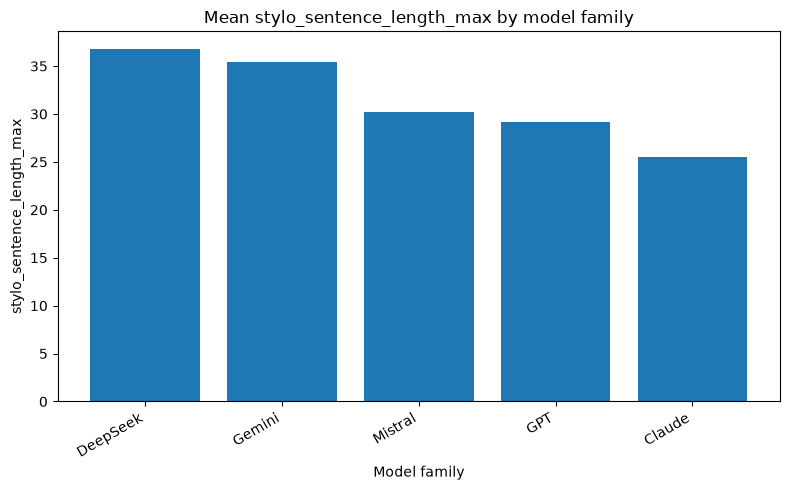

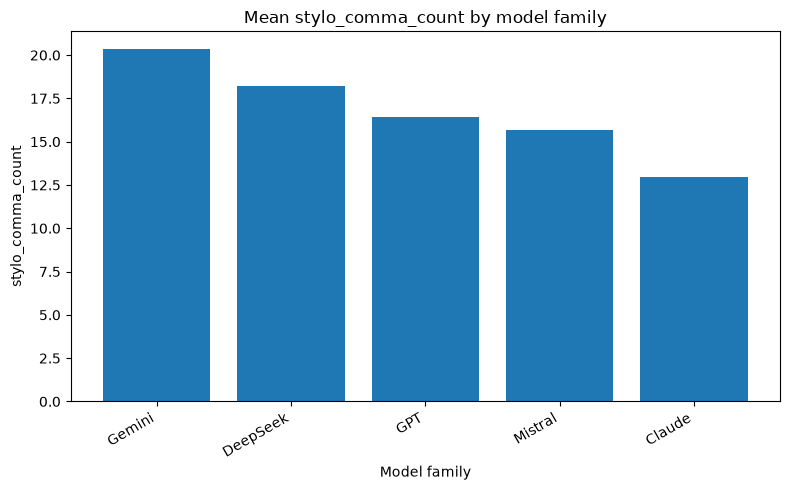

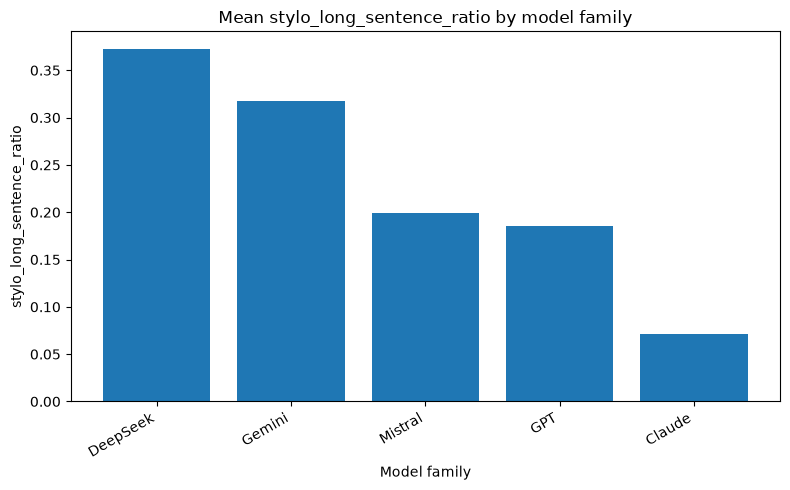

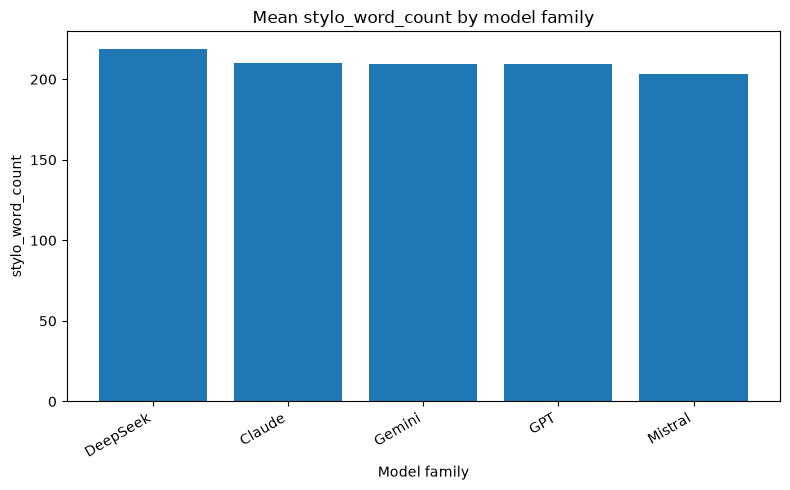

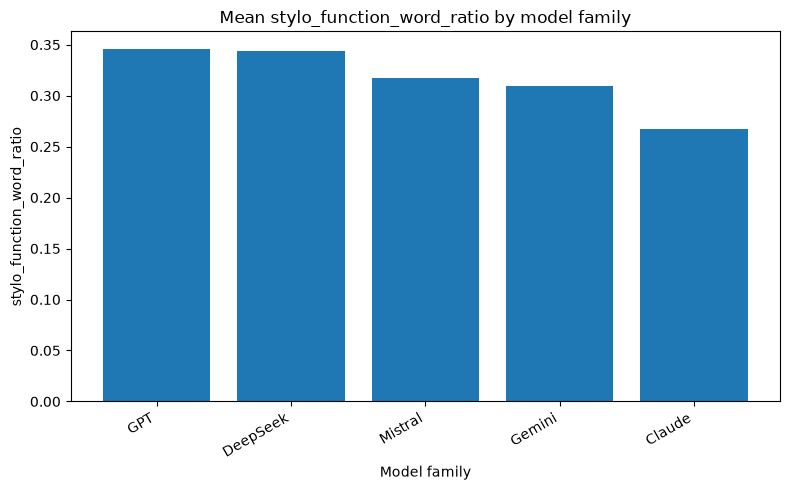

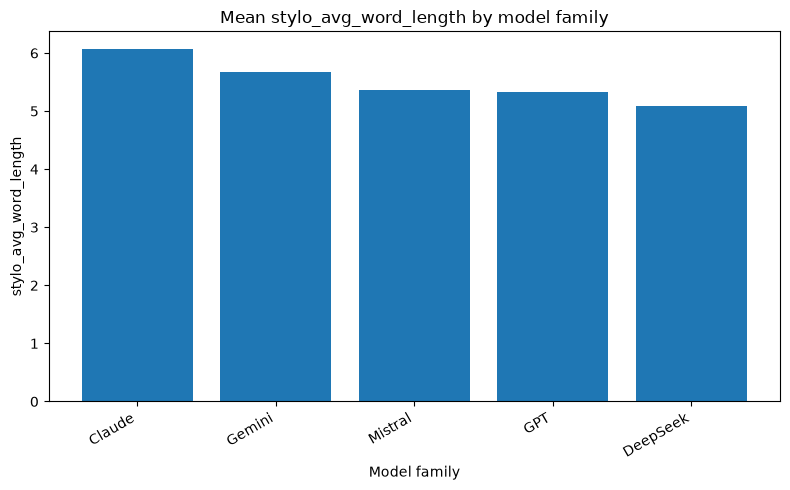

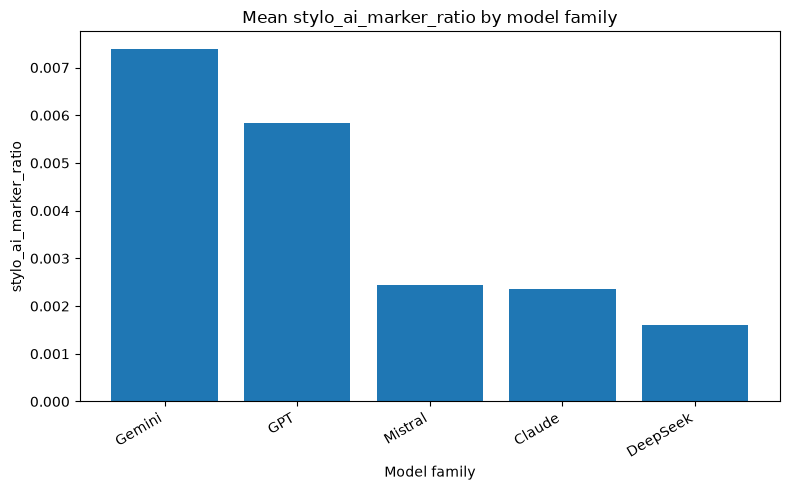

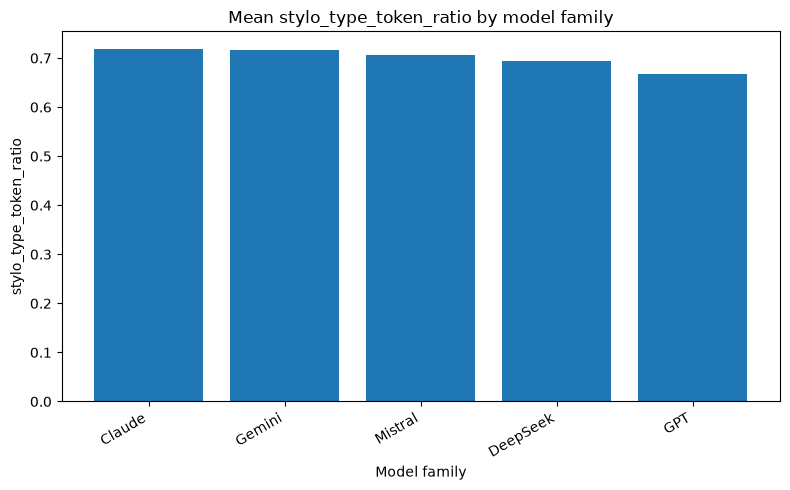

In [94]:
def plot_model_means_for_feature(feature: str) -> None:
    """
    Plot the mean value of one stylometric feature by model family.

    I convert the pandas index and values to plain Python/numpy objects before
    plotting. This avoids Pylance type warnings for matplotlib's `height`
    argument while preserving the same chart output.
    """
    summary = (
        features_df.groupby("model_family")[feature]
        .mean()
        .sort_values(ascending=False)
    )

    x_labels = summary.index.astype(str).tolist()
    y_values = summary.astype(float).to_numpy()

    plt.figure(figsize=(8, 5))
    plt.bar(x_labels, y_values)
    plt.xlabel("Model family")
    plt.ylabel(feature)
    plt.title(f"Mean {feature} by model family")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


for feature in selected_features:
    plot_model_means_for_feature(feature)


### Interpretation of selected feature plots

The selected feature plots make the model-family differences visually clear.

For `stylo_sentence_length_max`, DeepSeek is the highest model and Claude is the lowest. This visually confirms the statistical result that DeepSeek produces longer maximum sentence structures.

For `stylo_comma_count`, Gemini is clearly the highest and Claude is the lowest. This supports the interpretation that Gemini writes with more comma-linked clauses or more comma-dense prose.

For `stylo_long_sentence_ratio`, DeepSeek is again the highest, followed by Gemini. Claude is much lower than the other models. This confirms that Claude avoids long sentences more than the other model families, while DeepSeek and Gemini are more likely to produce longer syntactic units.

For `stylo_word_count`, DeepSeek is the highest and Mistral is the lowest. This means DeepSeek tends to generate longer final responses even though all models were controlled to stay in the same word-count range.

For `stylo_function_word_ratio`, GPT is the highest. This suggests that GPT uses a larger proportion of grammatical connector words relative to its total text length.

For `stylo_avg_word_length`, Claude is clearly the highest and DeepSeek is the lowest. This means Claude tends to use longer words on average, while DeepSeek's longer responses are not driven by longer words but by more words and longer sentence structures.

For `stylo_ai_marker_ratio`, Gemini is the highest, followed by GPT. The absolute values are small, so this should be interpreted carefully: the difference is statistically meaningful, but it does not mean Gemini outputs are dominated by AI-style markers.

For `stylo_type_token_ratio`, Claude is highest and GPT is lowest. This suggests that Claude has comparatively greater lexical variety, while GPT repeats relatively more vocabulary in this corpus.

Together, these plots support the formal statistical results and translate them into concrete model-level writing patterns.


## 6. Genre-specific robustness tests

The overall tests show strong model-family differences across the full corpus. However, because the dataset contains four genres, I also need to check whether the differences persist within genres.

The genre-specific tests repeat the Kruskal-Wallis model-family comparison separately for:

- Argumentative
- Descriptive
- Dialogue
- Narrative

This helps determine whether the model-family effects are robust, rather than being driven only by one genre.

In [95]:
genre_summary = (
    genre_tests.groupby("genre")
    .agg(
        total_features=("feature", "count"),
        significant_features=("significant_fdr_0_05", "sum"),
        mean_epsilon_squared=("epsilon_squared", "mean"),
        median_epsilon_squared=("epsilon_squared", "median"),
    )
    .reset_index()
)

genre_summary["share_significant"] = (
    genre_summary["significant_features"] / genre_summary["total_features"]
)

display(genre_summary)

,genre,total_features,significant_features,mean_epsilon_squared,median_epsilon_squared,share_significant
0,Argumentative,43,40,0.287779,0.270063,0.930233
1,Descriptive,43,37,0.201789,0.195496,0.860465
2,Dialogue,43,38,0.228209,0.251475,0.883721
3,Narrative,43,39,0.211995,0.241725,0.906977


### Interpretation of genre-specific results

The genre-specific tests show that model-family differences persist within each genre.

The strongest robustness result appears in the Argumentative genre, where 40 out of 43 features are significant, representing about 93.0% of the feature set. Narrative follows with 39 significant features, Dialogue has 38, and Descriptive has 37. Therefore, every genre still shows a large number of significant model-family differences.

The mean epsilon-squared value is also highest for Argumentative texts, followed by Dialogue, Narrative, and Descriptive. This suggests that model-family differences are especially strong when models produce argumentative writing, but the signal remains present across all four genres.

This is an important robustness check. It shows that the overall model-family result is not driven by one genre alone. The models preserve distinctive stylometric tendencies across Narrative, Descriptive, Argumentative, and Dialogue prompts.

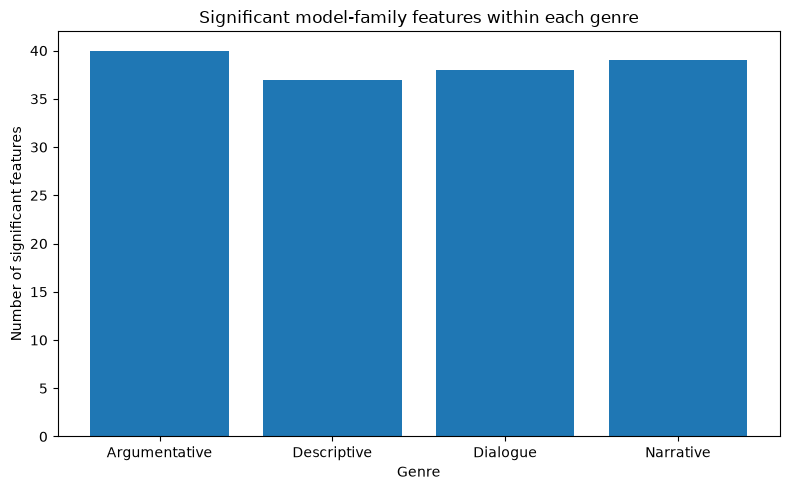

In [96]:
genre_labels = genre_summary["genre"].astype(str).tolist()
genre_values = genre_summary["significant_features"].astype(float).to_numpy()

plt.figure(figsize=(8, 5))
plt.bar(genre_labels, genre_values)
plt.xlabel("Genre")
plt.ylabel("Number of significant features")
plt.title("Significant model-family features within each genre")
plt.tight_layout()
plt.show()


### Interpretation of genre plot

The genre plot shows that each genre contains many significant model-family features.

The highest bar is **Argumentative**, with **40 out of 43** significant features. Narrative follows with **39**, Dialogue has **38**, and Descriptive has **37**. Although Descriptive is the lowest, it still has more than 86% of features significant.

The bars are all high, so the visual conclusion is clear: model identity remains detectable even when genre is held constant.

This matters because a model-specific writing style should not disappear when I analyze genres separately. The plot supports the claim that stylometric differences are robust across task types rather than being driven only by one genre.


In [97]:
top_by_genre = (
    genre_tests[genre_tests["significant_fdr_0_05"] == True]
    .sort_values(["genre", "p_value_fdr", "epsilon_squared"], ascending=[True, True, False])
    .groupby("genre")
    .head(5)
)

display(top_by_genre[
    [
        "genre",
        "feature",
        "p_value_fdr",
        "epsilon_squared",
        "effect_size_interpretation",
        "max_mean_model",
        "min_mean_model",
    ]
])

,genre,feature,p_value_fdr,epsilon_squared,effect_size_interpretation,max_mean_model,min_mean_model
0,Argumentative,stylo_period_per_100_words,1.965159e-29,0.600648,large,Claude,DeepSeek
1,Argumentative,stylo_period_count,3.030822e-29,0.591330,large,Claude,Gemini
2,Argumentative,stylo_function_word_count,4.273662e-29,0.585133,large,DeepSeek,Claude
3,Argumentative,stylo_function_word_ratio,1.966652e-27,0.551057,large,GPT,Claude
4,Argumentative,stylo_avg_sentence_length,3.236928e-27,0.543573,large,Gemini,Claude
43,Descriptive,stylo_avg_word_length,4.914826e-23,0.457321,large,Claude,DeepSeek
44,Descriptive,stylo_comma_count,1.300219e-22,0.447516,large,Gemini,Claude
45,Descriptive,stylo_period_per_100_words,8.540912e-22,0.430896,large,Claude,DeepSeek
46,Descriptive,stylo_comma_per_100_words,3.184718e-21,0.418285,large,Gemini,Claude
47,Descriptive,stylo_avg_sentence_length,1.010514e-20,0.407956,large,DeepSeek,Claude


### Interpretation of top genre-specific features

The top genre-specific features show that the strongest model-family signals vary somewhat by genre, but the same broad stylistic dimensions keep reappearing.

In **Argumentative** texts, the strongest features include period density, period count, function-word count, function-word ratio, and average sentence length. This suggests that argumentative writing exposes differences in sentence segmentation and discourse construction.

In **Descriptive** texts, the strongest features include average word length, comma count, period density, comma density, and average sentence length. This means descriptive writing highlights differences in lexical density and punctuation style.

In **Dialogue** texts, the strongest features include word count, long-sentence ratio, sentence-length variability, average sentence length, and punctuation density. This suggests that dialogue prompts expose differences in how models structure conversational prose.

In **Narrative** texts, the strongest features include average word length, character count, long-sentence ratio, comma count, and Flesch Reading Ease. This indicates that narrative writing exposes differences in lexical density, sentence structure, punctuation, and readability.

The important conclusion is that the same general families keep appearing: sentence structure, punctuation, lexical density, function words, and readability. The exact top features change by genre, but the broader model-family fingerprint remains stable.


In [98]:
overall_tests.to_csv(TABLE_DIR / "notebook_07_overall_statistical_tests.csv", index=False)
genre_summary.to_csv(TABLE_DIR / "notebook_07_genre_test_summary.csv", index=False)
top_by_genre.to_csv(TABLE_DIR / "notebook_07_top_features_by_genre.csv", index=False)
posthoc_results.to_csv(TABLE_DIR / "notebook_07_pairwise_posthoc_mannwhitney_tests.csv", index=False)
posthoc_summary.to_csv(TABLE_DIR / "notebook_07_pairwise_posthoc_summary.csv", index=False)
posthoc_feature_counts.to_csv(TABLE_DIR / "notebook_07_posthoc_significance_by_feature.csv", index=False)

if "family_summary" in globals():
    family_summary.to_csv(TABLE_DIR / "notebook_07_feature_family_summary.csv", index=False)

print("Saved notebook statistical summary tables to:", TABLE_DIR)

Saved notebook statistical summary tables to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/tables


## 7. Statistical conclusion

The formal statistical tests provide strong evidence that the five LLM families have distinguishable stylometric patterns.

Across **43 stylometric features**, **41 are significant** after Benjamini-Hochberg FDR correction. This means that approximately **95.35%** of the extracted writing-style features differ across model families even after controlling for multiple testing.

The effect sizes strengthen this conclusion. **Twenty-two features have large effects** and **seven have medium effects**. Therefore, the differences are not only statistically detectable but also practically meaningful.

The strongest model-family differences occur in:

- sentence length and sentence-length variability;
- comma and period usage;
- word count and character density;
- function-word usage;
- average word length;
- AI-style marker ratio;
- type-token ratio;
- readability-related features.

The results also provide interpretable model-level patterns. **DeepSeek** tends to produce longer and more structurally variable prose. **Gemini** is more comma-dense and has the highest selected AI-marker ratio. **Claude** has higher average word length, character density, and type-token ratio. **GPT** has the highest function-word ratio. **Mistral** is less dominant among the strongest individual signals and has the lowest mean word count among the selected top features.

The genre-specific tests confirm that these differences are robust. Argumentative texts have **40 out of 43** significant features, Narrative has **39**, Dialogue has **38**, and Descriptive has **37**. Therefore, the model-family signal persists within each genre rather than being driven by only one writing type.

The pairwise post-hoc tests provide an additional layer of evidence. Out of **100 Mann-Whitney U pairwise comparisons**, **86 are significant** after FDR correction. This shows that the strongest Kruskal-Wallis results are driven by concrete model-to-model differences, such as DeepSeek versus Claude on sentence length, Gemini versus Claude on comma density, GPT versus Claude on function-word ratio, and Claude versus DeepSeek on average word length.

My final interpretation is that model identity is strongly visible in the stylometric feature space. This complements the semantic-map notebook, where model families did not form strong semantic clusters. Together, the results suggest that LLMs answering the same prompts may be semantically similar, but they still leave measurable writing-style fingerprints.
